# Customer Churn Prediction

# Business Understanding

# Data Understanding

In [ ]:
# Install packages in Google Colab
# Cell output cleared as it only contains installation progress
!pip install tensorflow
!pip install keras
!pip install keras.preprocessing
!pip install scikeras[tensorflow]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Code to create kaggle path for data download
# Code taken from stackoverflow user fdsig
import json
import os
from pathlib import Path

# your api key
api_key = {
'username':"",
'key':""}

# uses pathlib Path
kaggle_path = Path('/root/.kaggle')
os.makedirs(kaggle_path, exist_ok=True)

# opens file and dumps python dict to json object
with open (kaggle_path/'kaggle.json', 'w') as handl:
    json.dump(api_key,handl)

os.chmod(kaggle_path/'kaggle.json', 600)

In [4]:
# Downloading kaggle dataset
!kaggle datasets download -d muhammadshahidazeem/customer-churn-dataset

# Creating parent folder directory for data unzip
!unzip customer-churn-dataset.zip -d customer-churn-dataset

Dataset URL: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
License(s): GPL-2.0
100% 6.66M/6.66M [00:02<00:00, 2.70MB/s]

Archive:  customer-churn-dataset.zip
  inflating: customer-churn-dataset/customer_churn_dataset-testing-master.csv  
  inflating: customer-churn-dataset/customer_churn_dataset-training-master.csv  


In [5]:
# Loading data
train_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-training-master.csv')
test_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-testing-master.csv')

In [6]:
train_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
test_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [8]:
[train_data.info()], [test_data.info()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  D

([None], [None])

In [9]:
train_data.isna().sum(), test_data.isna().sum()

(CustomerID           1
 Age                  1
 Gender               1
 Tenure               1
 Usage Frequency      1
 Support Calls        1
 Payment Delay        1
 Subscription Type    1
 Contract Length      1
 Total Spend          1
 Last Interaction     1
 Churn                1
 dtype: int64,
 CustomerID           0
 Age                  0
 Gender               0
 Tenure               0
 Usage Frequency      0
 Support Calls        0
 Payment Delay        0
 Subscription Type    0
 Contract Length      0
 Total Spend          0
 Last Interaction     0
 Churn                0
 dtype: int64)

In [10]:
train_data['Churn'].value_counts()

,count
Churn,
1.0,249999
0.0,190833


In [11]:
test_data['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


## Data Preprocessing

In [12]:
# Combining test and train data
data = pd.concat([train_data, test_data], axis=0)
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
64370,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
64371,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
64372,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [13]:
# Making copy of our data
df = data.copy()

# Dropping single NaN row
df = df.dropna().reset_index(drop=True)
df[df['CustomerID'].isna()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [14]:
# Lowercasing and replacing whitespace in columns
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [15]:
# Converting non-monetary numbers to integer dtype
col_list = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']

for col in col_list:
  df[col] = df[col].astype('int64')

In [16]:
df

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,2.0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3.0,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4.0,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5.0,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6.0,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
505201,64370.0,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505202,64371.0,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505203,64372.0,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505204,64373.0,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


## Exploratory data Analysis

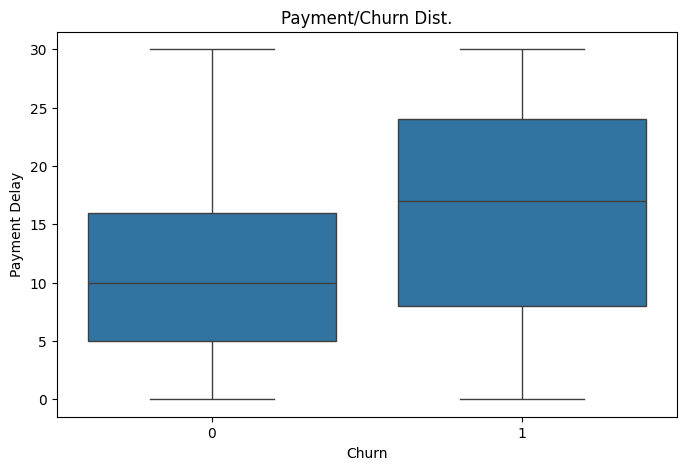

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(df, x='churn', y= 'payment_delay')

ax.set_title('Payment/Churn Dist.')
ax.set_xlabel('Churn')
ax.set_ylabel('Payment Delay');

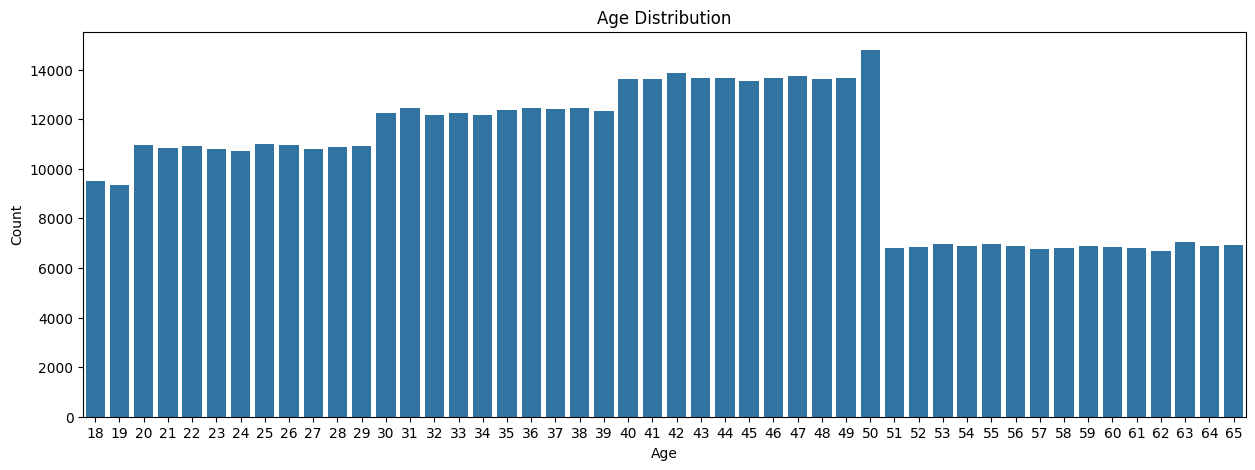

In [18]:
age_dict_vc = dict(df['age'].value_counts())
age_values = list(age_dict_vc.values())
age_keys = list(age_dict_vc.keys())

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(x=age_keys, y=age_values, ax=ax)

ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count');

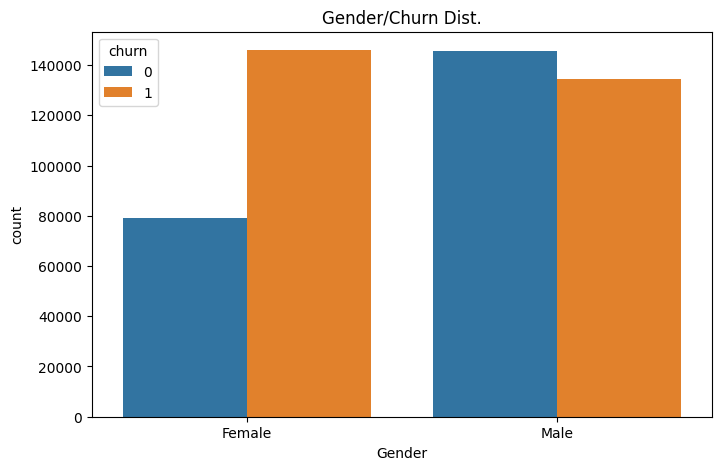

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(df, x='gender', hue='churn')

ax.set_title('Gender/Churn Dist.')
ax.set_xlabel('Gender');

# Data Preparation

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [21]:
# Splitting data
X = df.drop(['customerid', 'churn'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Both encode_and_concat_feature_train, and encode_and_concat_feature taken from Flatiron School lecture
def encode_and_concat_feature_train(X_train, feature_name):
    """
    Helper function for transforming training data. It takes in the full X dataframe and
    feature name, makes a one-hot encoder, and returns the encoder as well as the dataframe
    with that feature transformed into multiple columns of 1s and 0s
    """
    # make a one-hot encoder and fit it to the training data
    ohe = OneHotEncoder(categories="auto", handle_unknown="ignore")
    single_feature_df = X_train[[feature_name]]
    ohe.fit(single_feature_df)

    # call helper function that actually encodes the feature and concats it
    X_train = encode_and_concat_feature(X_train, feature_name, ohe)

    return ohe, X_train

def encode_and_concat_feature(X, feature_name, ohe):
    """
    Helper function for transforming a feature into multiple columns of 1s and 0s. Used
    in both training and testing steps. It Takes in the full X dataframe, feature name,
    and encoder, and returns the dataframe with that feature transformed into multiple
    columns of 1s and 0s
    """
    # create new one-hot encoded df based on the feature
    single_feature_df = X[[feature_name]]
    feature_array = ohe.transform(single_feature_df).toarray()
    ohe_df = pd.DataFrame(feature_array, columns=ohe.categories_[0], index=X.index)

    # drop the old feature from X and concat the new one-hot encoded df
    X = X.drop(feature_name, axis=1)
    X = pd.concat([X, ohe_df], axis=1)

    return X

encoders = {}

# Onehotencode data
def encode_data(data, cat_features):
    """
    Function for onehotencoding categorical features train or test data and
    appending to dataframe.
    """
    for feature in cat_features:
        ohe, data = encode_and_concat_feature_train(data, feature)
        encoders[feature] = ohe

    return data

In [23]:
categorical_features = ['gender', 'subscription_type', 'contract_length']

X_train = encode_data(X_train, categorical_features)
X_test = encode_data(X_test, categorical_features)

X_train

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,Female,Male,Basic,Premium,Standard,Annual,Monthly,Quarterly
166878,48,57,8,2,11,885.00,16,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
347476,33,43,13,0,1,684.44,23,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
254092,37,26,18,1,5,778.02,6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
146324,27,44,4,4,13,502.00,8,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
300199,35,56,2,0,1,603.26,27,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,41,44,18,2,13,717.39,3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
365838,45,44,14,3,13,995.38,8,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
131932,37,9,4,10,12,979.00,8,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
146867,33,27,5,10,20,824.00,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


# Modeling

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
from sklearn.model_selection import cross_val_score

### Base Logistic Regression

In [25]:
# Scaling data
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)

In [26]:
# Creating base logistic regression model
base_lr = LogisticRegression(random_state=42)

# Fitting data to base model
base_lr.fit(X_train_scaled, y_train)

# cross val score
base_lr_cv = cross_val_score(base_lr, X_train_scaled, y_train)
base_lr_cv

array([0.84914577, 0.84952928, 0.84912103, 0.84850247, 0.84970061])

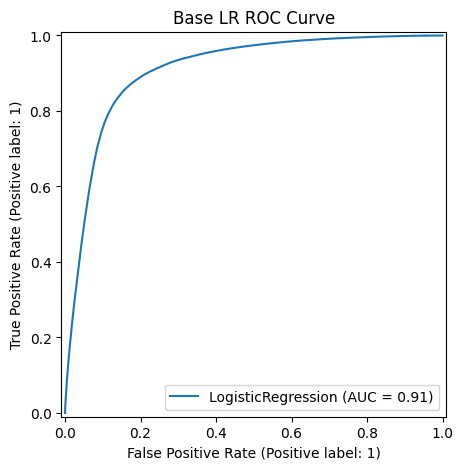

In [27]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(base_lr, X_train_scaled, y_train, ax=ax)

ax.set_title('Base LR ROC Curve');

### Base Random Forest Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [29]:
# Instantiate random forest classifier
base_rf_clf = RandomForestClassifier(random_state=42, max_samples=20000, max_depth=10)

# Fitting data to model
base_rf_clf.fit(X_train, y_train)

# Models cross validation scores
base_rf_clf_cv = cross_val_score(base_rf_clf, X_train, y_train)
base_rf_clf_cv

array([0.92636671, 0.92821001, 0.92858115, 0.9282595 , 0.92865449])

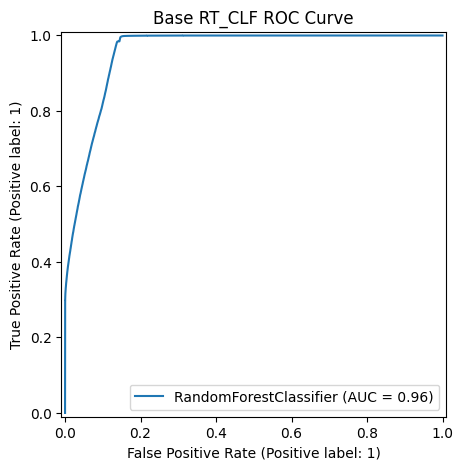

In [30]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(base_rf_clf, X_train, y_train, ax=ax)

ax.set_title('Base RT_CLF ROC Curve');

### Deep Learning Models

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [32]:
# Function to quickly plot model results
def plot_results(model_results):
    """
    This function will take in the results of a model and plot the loss and accuracy of the model.

    Args:
    model_results (list): the results of the model in [] brackets.
    """
    for results in model_results:
        train_loss = results.history['loss']
        train_acc = results.history['accuracy']
        val_loss = results.history['val_loss']
        val_acc = results.history['val_accuracy']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        sns.lineplot(x=results.epoch, y=train_loss, ax=ax1, label='train_loss')
        sns.lineplot(x=results.epoch, y=train_acc, ax=ax2, label='train_accuracy')

        sns.lineplot(x=results.epoch, y=val_loss, ax=ax1, label='val_loss')
        sns.lineplot(x=results.epoch, y=val_acc, ax=ax2, label='val_accuracy')
        ax1.set_title('Loss')
        ax2.set_title('Accuracy')
        ax1.legend();

In [33]:
# Creating validation data
X_train, val_data, y_train, val_labels = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [34]:
# Base sequential model
base_seq_model = Sequential([
                             layers.Input(shape=(X_train.shape[1],)),
                             layers.Dense(64, activation='relu'),
                             layers.Dense(32, activation='relu'),
                             layers.Dense(16, activation='relu'),
                             layers.Dense(1, activation='sigmoid')
                         ])

base_seq_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
base_seq_model_results = base_seq_model.fit(X_train, y_train,
                                            epochs=20,
                                            batch_size=1000,
                                            validation_data=(val_data, val_labels))

Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7712 - loss: 0.6243 - val_accuracy: 0.8313 - val_loss: 0.4067
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8532 - loss: 0.3825 - val_accuracy: 0.8635 - val_loss: 0.3610
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8610 - loss: 0.3678 - val_accuracy: 0.8628 - val_loss: 0.3558
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8662 - loss: 0.3577 - val_accuracy: 0.8789 - val_loss: 0.3359
Epoch 5/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8677 - loss: 0.3514 - val_accuracy: 0.8827 - val_loss: 0.3347
Epoch 6/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8755 - loss: 0.3370 - val_accuracy: 0.8829 - val_loss: 0.3234
Epoch 7/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8762 - loss: 0.3361 - val_accuracy: 0.8873 - val_loss: 0.3213
Epoch 8/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8831 - loss: 0.3225 - val_accuracy: 

In [36]:
base_seq_model.evaluate(X_test, y_test)

3158/3158 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9023 - loss: 0.2799


[0.27991893887519836, 0.9023376703262329]

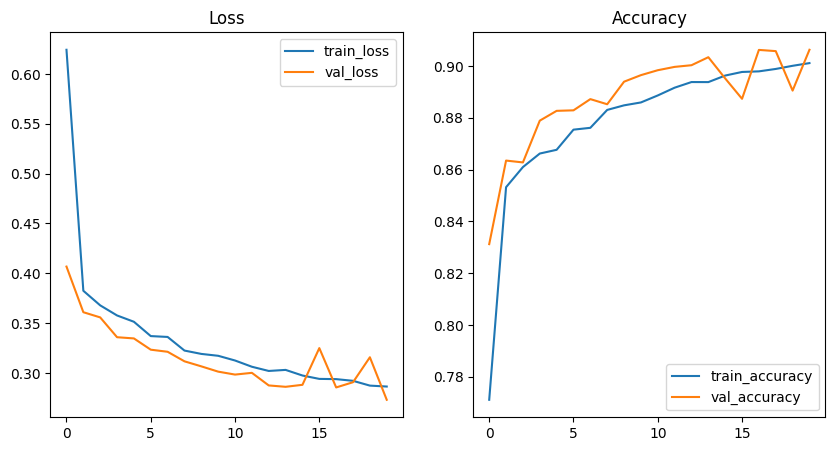

In [37]:
plot_results([base_seq_model_results])

In [38]:
# CNN model
base_cnn_model = Sequential([
                             layers.Input(shape=(X_train.shape[1], 1)),
                             layers.Conv1D(32, 2, activation='relu'),
                             layers.MaxPooling1D(),

                             layers.Conv1D(64, 2, activation='relu'),
                             layers.MaxPooling1D(),

                             layers.Flatten(),
                             layers.Dense(64, activation='relu'),
                             layers.Dense(32, activation='relu'),
                             layers.Dense(16, activation='relu'),
                             layers.Dense(1, activation='sigmoid')
])

base_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
base_cnn_model_results = base_cnn_model.fit(X_train, y_train,
                                            epochs=20,
                                            batch_size=1000,
                                            validation_data=(val_data, val_labels))

Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7736 - loss: 0.4891 - val_accuracy: 0.8080 - val_loss: 0.4399
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8346 - loss: 0.3980 - val_accuracy: 0.8487 - val_loss: 0.3708
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8505 - loss: 0.3711 - val_accuracy: 0.8388 - val_loss: 0.3813
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8623 - loss: 0.3532 - val_accuracy: 0.8713 - val_loss: 0.3337
Epoch 5/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8728 - loss: 0.3331 - val_accuracy: 0.8803 - val_loss: 0.3184
Epoch 6/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8781 - loss: 0.3233 - val_accuracy: 0.8796 - val_loss: 0.3221
Epoch 7/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8834 - loss: 0.3126 - val_accuracy: 0.8883 - val_loss: 0.3020
Epoch 8/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8895 - loss: 0.3023 - val_accuracy: 0

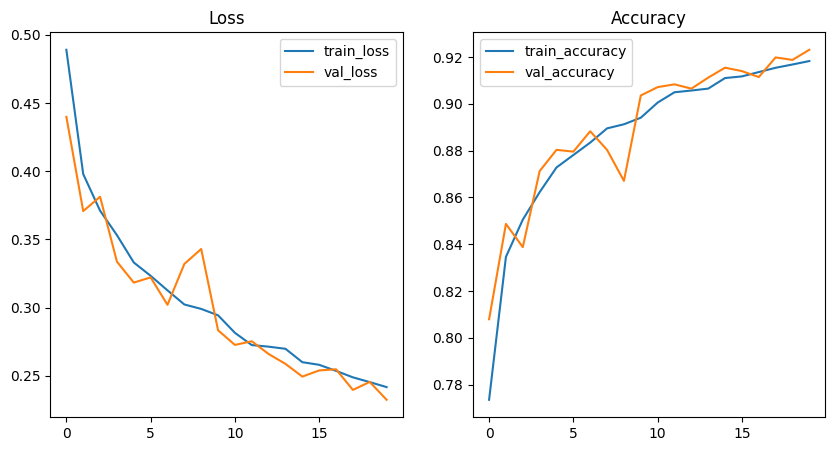

In [40]:
plot_results([base_cnn_model_results])

In [41]:
base_cnn_model.evaluate(X_test, y_test)

3158/3158 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9199 - loss: 0.2367


[0.23669332265853882, 0.9198848009109497]

## Random Forest Grid Search

The Gridsearch process has been commented out as it takes about 2 hours to run to completion, but the results of the grid search is what is used for the final random forest model.

In [42]:
#from sklearn.model_selection import GridSearchCV

In [43]:
#rf_clf = RandomForestClassifier(random_state=42, max_samples=20000)

In [44]:
#rf_param_grid = {
#    'criterion': ['gini', 'entropy', 'log_loss'],
#    'max_depth': [None, 2, 3, 4, 5, 6],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 3, 4, 5, 6],
#    'class_weight': ['balanced', 'balanced_subsample']
#}


In [45]:
#rf_grid_search = GridSearchCV(rf_clf, rf_param_grid, cv=5, n_jobs=2)

In [46]:
# Take almost 2hours to run
#rf_grid_search.fit(X_train, y_train)

In [47]:
#rf_grid_search.best_params_

# Final Model Random Forest Classifier

In [48]:
# Takes about 4min to run
# Instantiate random forest classifier
rf_clf_final = RandomForestClassifier(random_state=42, class_weight='balanced_subsample', criterion='gini', min_samples_leaf=1, min_samples_split=5)

rf_clf_final.fit(X_train, y_train)

rf_clf_final_cv = cross_val_score(rf_clf_final, X_train, y_train)
rf_clf_final_cv

array([0.93433677, 0.93594502, 0.93487196, 0.93558674, 0.93484447])

# Evaluation

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [50]:
# Setting final model for evaluation
final_model = rf_clf_final

# Getting cross val scores for test data
final_model_cv = cross_val_score(final_model, X_test, y_test)
final_model_cv

array([0.92943738, 0.93210946, 0.92799881, 0.93121536, 0.93200713])

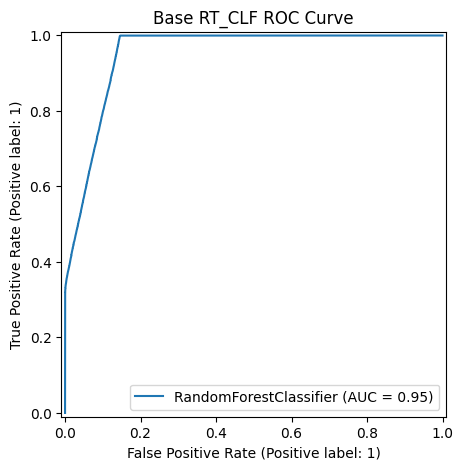

In [51]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax)

ax.set_title('Base RT_CLF ROC Curve');

In [52]:
# Getting model test data predictions
y_pred = final_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred.round()))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     44981
           1       0.90      1.00      0.94     56061

    accuracy                           0.93    101042
   macro avg       0.94      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



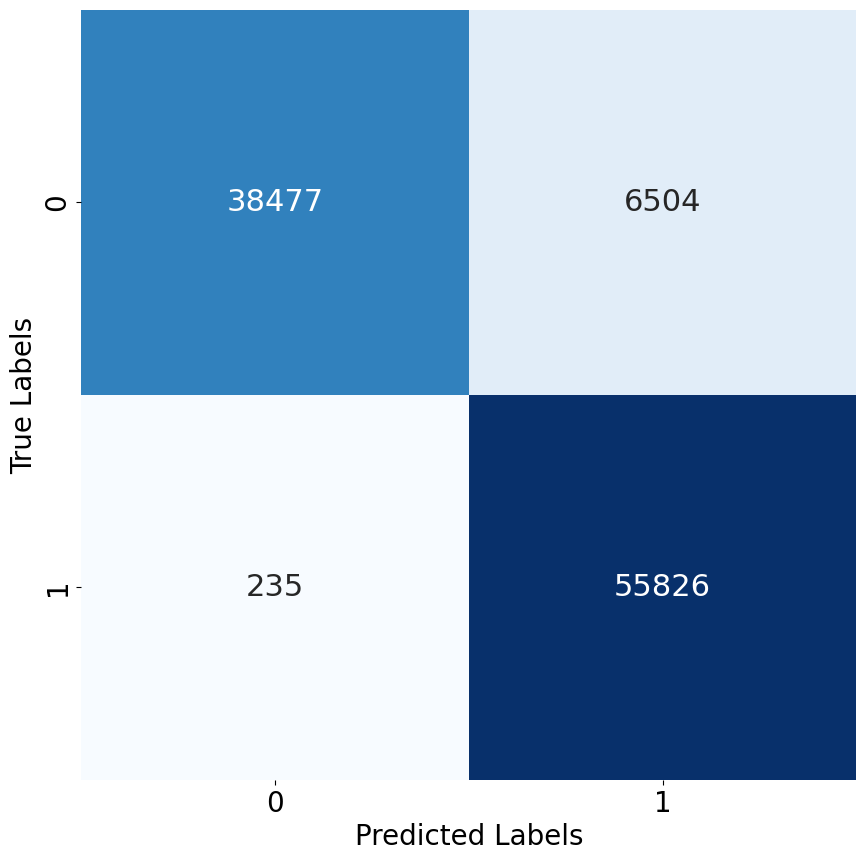

In [53]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred.round())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size' : 22}, cbar=False)

ax.tick_params(axis='both', labelsize=20)
ax.set_xlabel('Predicted Labels', fontsize=20)
ax.set_ylabel('True Labels', fontsize=20);

## Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#import joblib # to export pipeline

In [24]:
numerical_features = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'total_spend', 'last_interaction']
categorical_features = ['gender', 'subscription_type', 'contract_length']

In [26]:
encoder_pipe = Pipeline([
    ('encode', encode_data(X_train, categorical_features))
])

preprocessor = ColumnTransformer([
    ('encode', encoder_pipe, categorical_features)
])

In [33]:
pipe = Pipeline([
    ('encode', encode_data(X_train, categorical_features)),
    ('scale', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced_subsample', criterion='gini', min_samples_leaf=1, min_samples_split=5))
])

## Limitations

## Next Steps

# Conclusion